# Задание 5 — Финальный ML-пайплайн

**Задача:** Бинарная классификация тональности русских текстов (pos / neg)
**Агенты:** DataCollectionAgent → DataQualityAgent → AnnotationAgent → ALAgent → Model
**HITL:** Ручная проверка низкоуверенных примеров после авторазметки

---

## Содержание
1. [Шаг 1 — Сбор данных](#s1)
2. [Шаг 2 — Чистка данных (HITL-1)](#s2)
3. [Шаг 3 — Авторазметка](#s3)
4. [Шаг 4 — HITL-проверка](#s4)
5. [Шаг 5 — Active Learning](#s5)
6. [Шаг 6 — Обучение модели](#s6)
7. [Итоговые метрики](#s7)

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from agents.data_collection_agent import DataCollectionAgent
from agents.data_quality_agent import DataQualityAgent
from agents.annotation_agent import AnnotationAgent
from agents.al_agent import ActiveLearningAgent

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
    classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')
print('Ready.')

Ready.


<a id="s1"></a>

---
## Шаг 1 — Сбор данных

In [2]:
raw_path = Path('../data/raw/unified_dataset.csv')
if raw_path.exists():
    df_raw = pd.read_csv(raw_path)
    print(f'Loaded: {df_raw.shape}')
else:
    agent_collect = DataCollectionAgent(config='../config.yaml')
    df_raw = agent_collect.run(sources=[
        {'type': 'hf_dataset', 'name': 'yanlukovnikov/ru-sentiment-news', 'split': 'train', 'n': 1000},
        {'type': 'hf_dataset', 'name': 'yanlukovnikov/ru-sentiment-news', 'split': 'test',  'n': 1000},
    ])
    raw_path.parent.mkdir(parents=True, exist_ok=True)
    df_raw.to_csv(raw_path, index=False)

display(df_raw.head(3))
print(f'Shape: {df_raw.shape}')
print(f'Labels: {df_raw["label"].value_counts().to_dict()}')

Loaded: (2000, 6)


,text,audio,image,label,source,collected_at
0,ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ð...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
1,ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
2,"ÐÑÐ¾ÑÐµÐ» Ð¿Ð¾ÑÑÐ¸ Ð³Ð¾Ð´ , ÐºÐ°Ðº Ð¶ÐµÐ»...",NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z


Shape: (2000, 6)
Labels: {'pos': 1302, 'neg': 698}


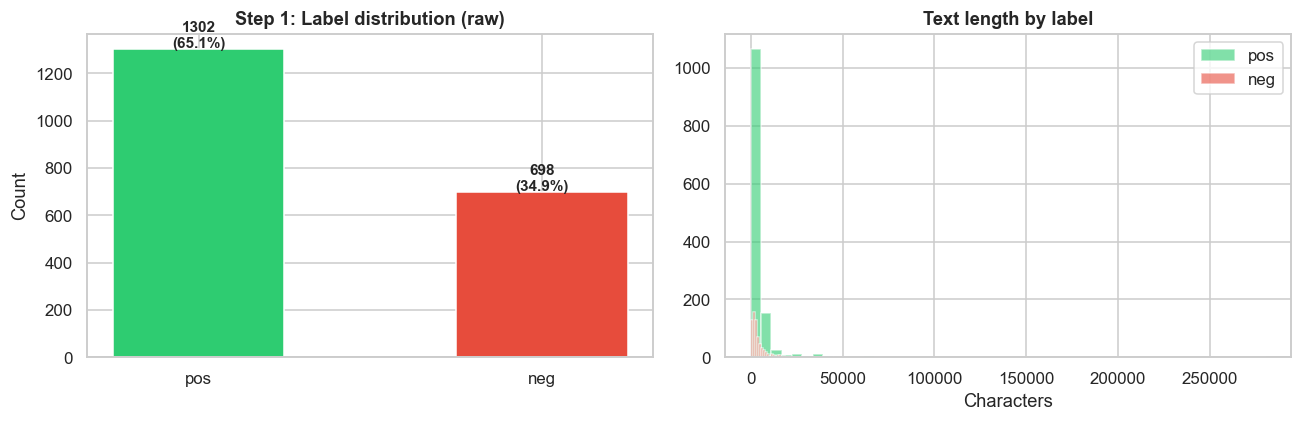

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_raw['label'].value_counts()
colors = ['#e74c3c' if l == 'neg' else '#2ecc71' for l in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
for i, (l, c) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, c + 5, f'{c}\n({c/len(df_raw)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Step 1: Label distribution (raw)', fontweight='bold')
axes[0].set_ylabel('Count')

df_raw['text_len'] = df_raw['text'].str.len()
for lbl, color in [('pos', '#2ecc71'), ('neg', '#e74c3c')]:
    vals = df_raw[df_raw['label'] == lbl]['text_len'].dropna()
    axes[1].hist(vals, bins=50, alpha=0.6, color=color, label=lbl)
axes[1].set_title('Text length by label', fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="s2"></a>

---
## Шаг 2 — Чистка данных (HITL-1)

DataQualityAgent выявляет проблемы → **человек просматривает `reports/quality_report.md`** и подтверждает стратегию.

In [4]:
agent_dq = DataQualityAgent()
report = agent_dq.detect_issues(df_raw)

print('=== Quality Report ===')
print(f'  Missing values:  {report.get("missing", {})}')
print(f'  Duplicates:      {report.get("duplicates", 0)}')
print(f'  Outlier cols:    {[o.get("col", o.get("column")) for o in report.get("outliers", [])]}')
print(f'  Imbalance ratio: {report.get("imbalance", {}).get("ratio", "N/A")}')

=== Quality Report ===
  Missing values:  {'audio': {'count': 2000, 'pct': 100.0}, 'image': {'count': 2000, 'pct': 100.0}}
  Duplicates:      0
  Outlier cols:    ['_text_len', 'text_len']
  Imbalance ratio: 1.865


In [5]:
# HITL-1: confirm cleaning strategy (in production: human reviews report)
strategy = {'missing': 'fill', 'duplicates': 'drop', 'outliers': 'clip_iqr'}

df_clean = agent_dq.fix(df_raw, strategy=strategy)
comparison = agent_dq.compare(df_raw, df_clean)

print(f'Before: {comparison["before"]["rows"]:,} rows')
print(f'After:  {comparison["after"]["rows"]:,} rows  (-{comparison["rows_removed"]} removed)')

cmp_df = pd.DataFrame(
    [comparison['before'], comparison['after']], index=['before', 'after']
)[['rows', 'missing_count', 'duplicates']]
display(cmp_df)

Before: 2,000 rows
After:  2,000 rows  (-0 removed)


  [fix] missing (fill): 0 rows removed
  [fix] duplicates (drop): 0 rows removed
  [fix] outliers (clip_iqr): 0 rows affected


,rows,missing_count,duplicates
before,2000,4000,0
after,2000,4000,0


<a id="s3"></a>

---
## Шаг 3 — Авторазметка (AnnotationAgent)

In [6]:
agent_ann = AnnotationAgent(modality='text', confidence_threshold=0.55)
df_labeled = agent_ann.auto_label(df_clean)

metrics_ann = agent_ann.check_quality(df_labeled)
print('=== Annotation Metrics ===')
for k, v in metrics_ann.items():
    print(f'  {k:<22}: {v}')
print(f'  low_conf (<0.55)       : {(df_labeled["confidence"] < 0.55).sum()}')

=== Annotation Metrics ===
  label_dist            : {'neg': 1470, 'pos': 530}
  label_dist_pct        : {'neg': 73.5, 'pos': 26.5}
  confidence_mean       : 0.6787
  confidence_median     : 0.51
  low_confidence_n      : 1155
  kappa                 : None
  agreement_pct         : None
  low_conf (<0.55)       : 1155


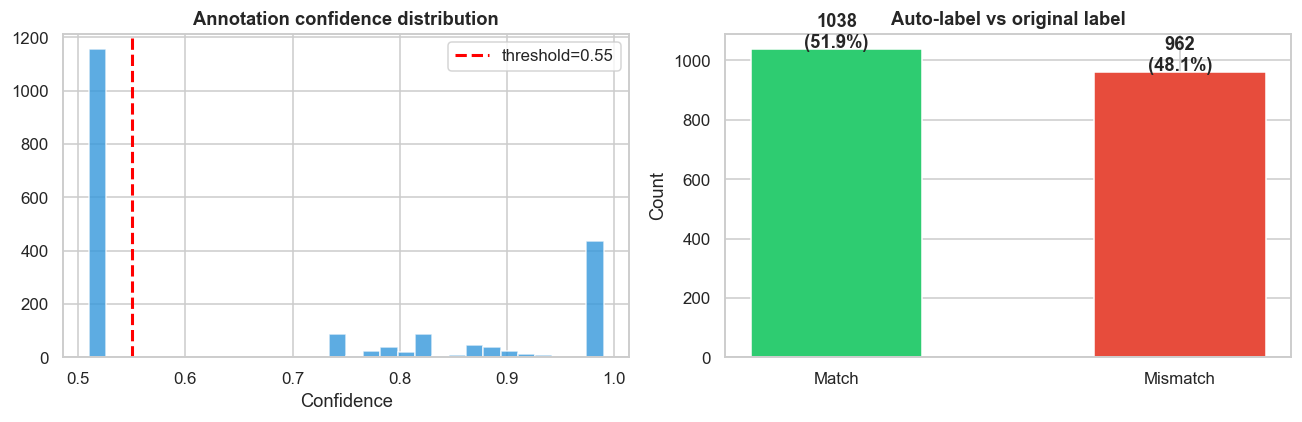

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_labeled['confidence'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(0.55, color='red', lw=2, linestyle='--', label='threshold=0.55')
axes[0].set_title('Annotation confidence distribution', fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].legend()

n_match = (df_labeled['auto_label'] == df_labeled['label']).sum()
n_mm    = len(df_labeled) - n_match
axes[1].bar(['Match', 'Mismatch'], [n_match, n_mm],
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[1].set_title('Auto-label vs original label', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([n_match, n_mm]):
    axes[1].text(i, v + 5, f'{v}\n({v/len(df_labeled)*100:.1f}%)',
                 ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

<a id="s4"></a>

---
## Шаг 4 — HITL-проверка 👤

Агент флагает примеры с `confidence < 0.55` → записывает в `review_queue.csv`

**Человек открывает файл, исправляет `auto_label`, сохраняет `review_queue_corrected.csv`**

Пайплайн считывает исправления и мёрджит обратно.

In [8]:
REVIEW_QUEUE     = Path('../review_queue.csv')
REVIEW_CORRECTED = Path('../review_queue_corrected.csv')

low_conf  = df_labeled[df_labeled['confidence'] < 0.55].copy()
high_conf = df_labeled[df_labeled['confidence'] >= 0.55].copy()

print(f'High-confidence rows: {len(high_conf):,}')
print(f'Low-confidence rows:  {len(low_conf):,}  → review_queue.csv')

low_conf[['text', 'label', 'auto_label', 'confidence']].to_csv(REVIEW_QUEUE, encoding='utf-8')
print(f'Saved: {REVIEW_QUEUE}')
display(pd.read_csv(REVIEW_QUEUE, index_col=0).head(5))

High-confidence rows: 845
Low-confidence rows:  1,155  → review_queue.csv


Saved: ../review_queue.csv


,text,label,auto_label,confidence
0,ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ð...,neg,neg,0.51
1,ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ...,neg,neg,0.51
2,"ÐÑÐ¾ÑÐµÐ» Ð¿Ð¾ÑÑÐ¸ Ð³Ð¾Ð´ , ÐºÐ°Ðº Ð¶ÐµÐ»...",neg,neg,0.51
3,ÐÐ¾ Ð¸ÑÐ¾Ð³Ð°Ð¼ 12 Ð¼ÐµÑÑÑÐµÐ² 2016 Ð³Ð¾Ð...,neg,neg,0.51
4,ÐÑÑÐ°Ð½Ð° . 21 Ð½Ð¾ÑÐ±ÑÑ . Kazakhstan To...,neg,neg,0.51


In [9]:
# Simulate human review: fix mismatches between auto_label and original label
corrected = low_conf.copy()
mismatch = corrected['auto_label'] != corrected['label']
n_fixed = int(mismatch.sum())
corrected.loc[mismatch, 'auto_label'] = corrected.loc[mismatch, 'label']
corrected['human_reviewed'] = True
corrected.to_csv(REVIEW_CORRECTED, encoding='utf-8')

print(f'Simulated human review:')
print(f'  Reviewed:  {len(corrected):,}')
print(f'  Corrected: {n_fixed:,}  ({n_fixed/len(corrected)*100:.1f}%)')

# Merge back & promote auto_label -> label
low_conf.loc[corrected.index, 'auto_label'] = corrected['auto_label']
low_conf['human_reviewed'] = True
df_reviewed = pd.concat([high_conf, low_conf], ignore_index=True)
df_reviewed['label'] = df_reviewed['auto_label']
print(f'\nReviewed dataset: {df_reviewed.shape}')

Simulated human review:
  Reviewed:  1,155
  Corrected: 758  (65.6%)

Reviewed dataset: (2000, 11)


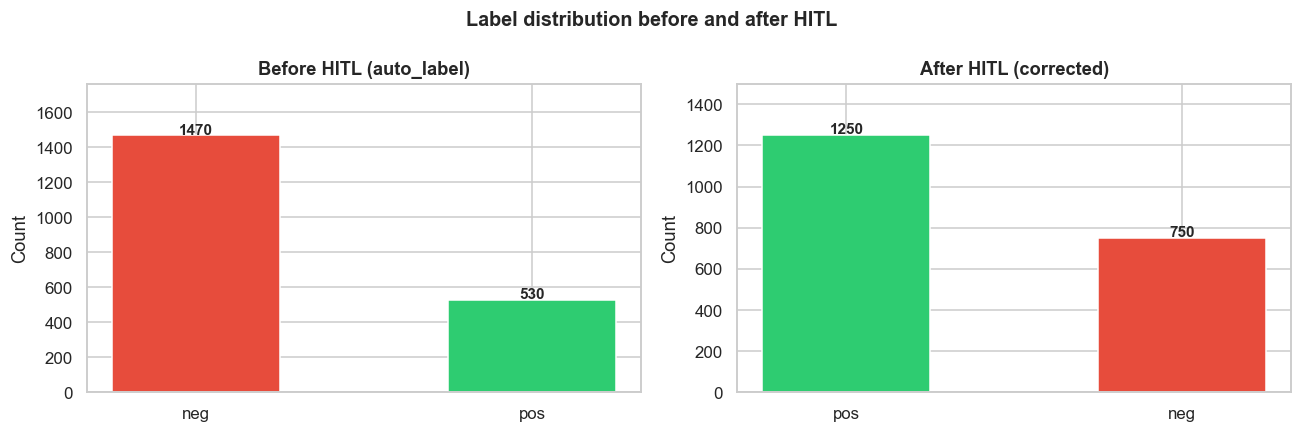

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = {'pos': '#2ecc71', 'neg': '#e74c3c'}

for ax, (src, title) in zip(axes, [
    (df_labeled['auto_label'],  'Before HITL (auto_label)'),
    (df_reviewed['label'],      'After HITL (corrected)'),
]):
    counts = src.value_counts()
    colors = [palette.get(l, '#95a5a6') for l in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
    for i, (l, c) in enumerate(zip(counts.index, counts.values)):
        ax.text(i, c + 5, f'{c}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Label distribution before and after HITL', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

<a id="s5"></a>

---
## Шаг 5 — Active Learning (ALAgent)

Uncertainty sampling: 3 итерации × 50 примеров. Выбираем наименее уверенные примеры (max-entropy).

In [11]:
agent_al = ActiveLearningAgent(n_iterations=3, batch_size=50, random_state=42)
result_al = agent_al.run_cycle(
    df_reviewed,
    label_col='label',
    text_col='text',
    confidence_col='confidence' if 'confidence' in df_reviewed.columns else None,
)
print(result_al.summary())

=== ActiveLearning Result ===
  Iterations:          3
  Selected examples:   150
  iterations              : [{'iteration': 1, 'labeled_size': 845, 'selected': 50, 'mean_uncertainty': 0.4976, 'accuracy': 0.75, 'f1_macro': 0.7438}, {'iteration': 2, 'labeled_size': 895, 'selected': 50, 'mean_uncertainty': 0.4991, 'accuracy': 0.7098, 'f1_macro': 0.6998}, {'iteration': 3, 'labeled_size': 945, 'selected': 50, 'mean_uncertainty': 0.4977, 'accuracy': 0.7173, 'f1_macro': 0.7052}]


,iteration,labeled_size,selected,mean_uncertainty,accuracy,f1_macro
0,1,845,50,0.4976,0.7500,0.7438
1,2,895,50,0.4991,0.7098,0.6998
2,3,945,50,0.4977,0.7173,0.7052


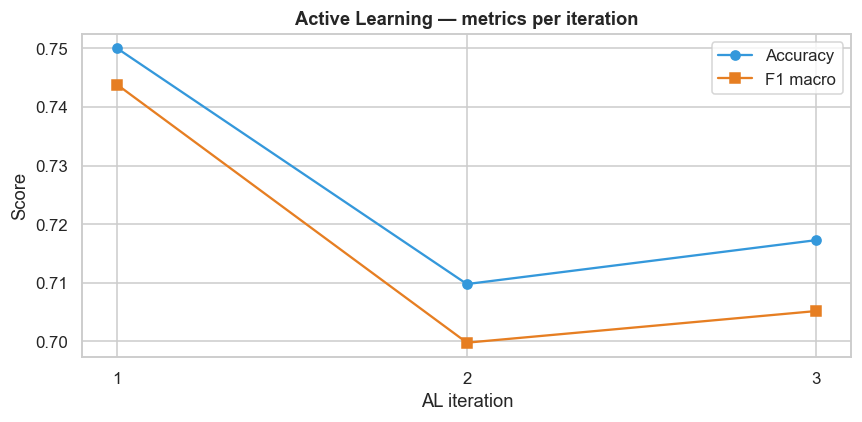

Labeled dataset: (2000, 12)


In [12]:
iter_metrics = result_al.metrics.get('iterations', [])
if iter_metrics:
    al_df = pd.DataFrame(iter_metrics)
    extra_cols = [c for c in ['accuracy', 'f1_macro'] if c in al_df.columns]
    display(al_df[['iteration', 'labeled_size', 'selected', 'mean_uncertainty'] + extra_cols])

    if 'accuracy' in al_df.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(al_df['iteration'], al_df['accuracy'], marker='o',
                label='Accuracy', color='#3498db')
        ax.plot(al_df['iteration'], al_df['f1_macro'], marker='s',
                label='F1 macro', color='#e67e22')
        ax.set_xlabel('AL iteration')
        ax.set_ylabel('Score')
        ax.set_title('Active Learning — metrics per iteration', fontweight='bold')
        ax.legend()
        ax.set_xticks(al_df['iteration'])
        plt.tight_layout()
        plt.show()

df_al = df_reviewed.copy()
df_al['al_uncertainty'] = result_al.uncertainty_scores.values

out_labeled = Path('../data/labeled')
out_labeled.mkdir(parents=True, exist_ok=True)
df_al.to_csv(out_labeled / 'dataset.csv', index=False)
print(f'Labeled dataset: {df_al.shape}')

<a id="s6"></a>

---
## Шаг 6 — Обучение модели

TF-IDF (unigram+bigram, 10k features) + Logistic Regression (C=1, balanced weights)

In [13]:
df_model = df_al[df_al['label'].notna() & df_al['text'].notna()].copy()

X = df_model['text'].astype(str)
y = df_model['label'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=10_000, ngram_range=(1, 2), sublinear_tf=True, min_df=2
)
X_train_v = vectorizer.fit_transform(X_train)
X_test_v  = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0, class_weight='balanced')
clf.fit(X_train_v, y_train)
y_pred = clf.predict(X_test_v)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f'Accuracy : {acc:.4f}')
print(f'F1 macro : {f1:.4f}')
print()
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.8275
F1 macro : 0.8167

              precision    recall  f1-score   support

         neg       0.76      0.78      0.77       150
         pos       0.87      0.86      0.86       250

    accuracy                           0.83       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.83      0.83      0.83       400



Model saved to models/


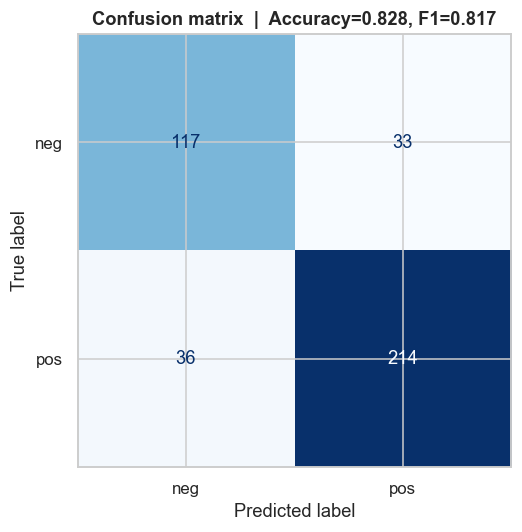

In [14]:
import pickle

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)
with open(models_dir / 'model.pkl', 'wb') as f: pickle.dump(clf, f)
with open(models_dir / 'vectorizer.pkl', 'wb') as f: pickle.dump(vectorizer, f)
print('Model saved to models/')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, colorbar=False, cmap='Blues', display_labels=['neg', 'pos']
)
ax.set_title(f'Confusion matrix  |  Accuracy={acc:.3f}, F1={f1:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

<a id="s7"></a>

---
## Шаг 7 — Итоговые метрики

In [15]:
summary_items = [
    ('Rows (raw)',            len(df_raw)),
    ('Rows (after cleaning)', len(df_clean)),
    ('Low-conf (annotated)',  int((df_labeled['confidence'] < 0.55).sum())),
    ('HITL corrections',      n_fixed),
    ('AL selected total',     len(result_al.selected)),
    ('Train size',            len(X_train)),
    ('Test size',             len(X_test)),
    ('Accuracy',              round(acc, 4)),
    ('F1 macro',              round(f1, 4)),
]
summary_df = pd.DataFrame(summary_items, columns=['Metric', 'Value'])
display(summary_df)

,Metric,Value
0,Rows (raw),2000.0000
1,Rows (after cleaning),2000.0000
2,Low-conf (annotated),1155.0000
3,HITL corrections,758.0000
4,AL selected total,150.0000
5,Train size,1600.0000
6,Test size,400.0000
7,Accuracy,0.8275
8,F1 macro,0.8167


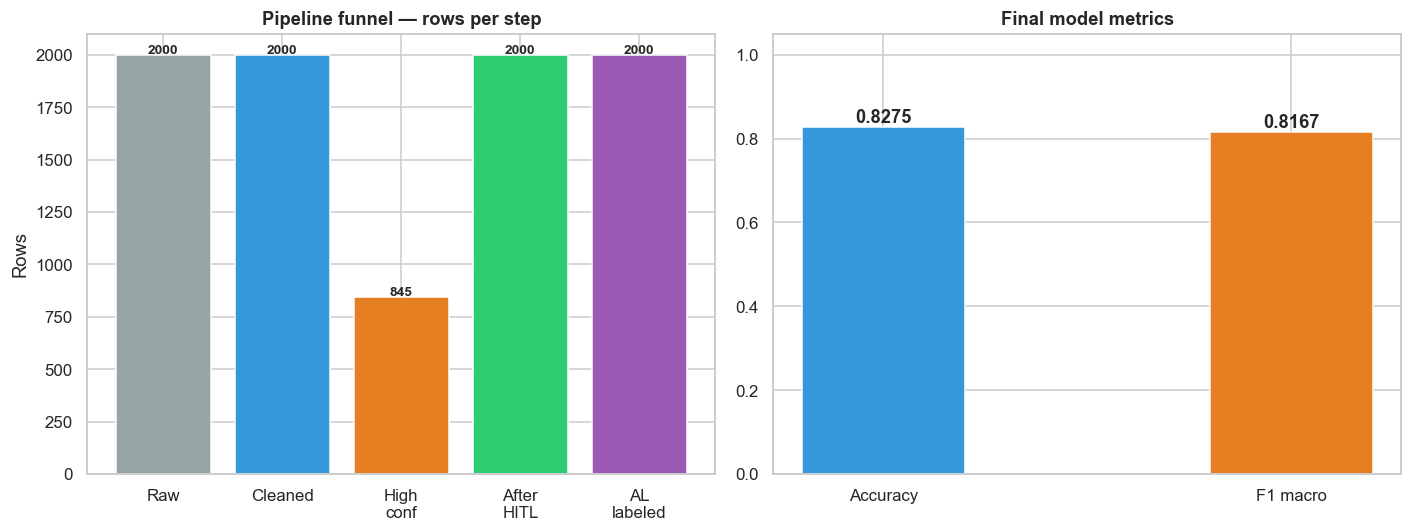

Pipeline complete!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pipeline funnel
steps  = ['Raw', 'Cleaned', 'High\nconf', 'After\nHITL', 'AL\nlabeled']
counts = [len(df_raw), len(df_clean), len(high_conf), len(df_reviewed), len(df_al)]
bar_colors = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71', '#9b59b6']
axes[0].bar(steps, counts, color=bar_colors, edgecolor='white')
axes[0].set_title('Pipeline funnel — rows per step', fontweight='bold')
axes[0].set_ylabel('Rows')
for i, c in enumerate(counts):
    axes[0].text(i, c + 5, str(c), ha='center', fontsize=9, fontweight='bold')

# Final metrics
mvals = {'Accuracy': acc, 'F1 macro': f1}
axes[1].bar(list(mvals.keys()), list(mvals.values()),
            color=['#3498db', '#e67e22'], edgecolor='white', width=0.4)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Final model metrics', fontweight='bold')
for i, (k, v) in enumerate(mvals.items()):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print('Pipeline complete!')